# 볼록함수, 선적분의 기본정리, 발산정리 (뉴진수 12강)-14강 3기 12강

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

x, y, z, t, u, v = sp.symbols("x y z t u v", real=True)

## 1. 할선 기울기와 접선 기울기를 식으로 비교하기
볼록함수에서 점 $u$ 의 접선 위 높이 $f(u)+f'(u)(v-u)$ 와 곡선 위 높이 $f(v)$ 를 비교합니다.
볼록함수($f''>0$)이면 곡선이 접선보다 위에 있어 차이 $g(v)=f(v)-[f(u)+f'(u)(v-u)]\ge 0$.

In [2]:
f = x**2                                   # convex sample: f'' = 2 > 0
fp = sp.diff(f, x)
u0 = sp.Rational(1, 2)
tangent = f.subs(x, u0) + fp.subs(x, u0) * (x - u0)   # tangent line at u0
gap = sp.expand(f - tangent)               # curve minus tangent
print("f(x)        =", f)
print("tangent@1/2 =", sp.expand(tangent))
print("f - tangent =", sp.factor(gap), "  >= 0 everywhere (so curve sits above tangent)")
# secant slope on [u, v] vs tangent slope f'(u)
us, vs = sp.Rational(1, 2), 2
sec = (f.subs(x, vs) - f.subs(x, us)) / (vs - us)
print("secant slope [1/2,2] =", sec, "   tangent slope f'(1/2) =", fp.subs(x, u0))

f(x)        = x**2
tangent@1/2 = x - 1/4
f - tangent = (2*x - 1)**2/4   >= 0 everywhere (so curve sits above tangent)
secant slope [1/2,2] = 5/2    tangent slope f'(1/2) = 1


## 2. 선분이 그래프 위에 있는가, 그래프 아래에 있는가
표준 정의 $f(tx+(1-t)y)\le t f(x)+(1-t)f(y)$ 를 $f=x^2$, $x=-1,\ y=2$ 로 검산.
선형보간(현)에서 함수값을 뺀 차가 $0\le t\le1$ 에서 항상 $\ge 0$ 이면 볼록.

In [3]:
xa, yb = -1, 2
chord = t * f.subs(x, xa) + (1 - t) * f.subs(x, yb)        # linear interpolation
midval = f.subs(x, t * xa + (1 - t) * yb)                  # f on the segment
diff = sp.expand(chord - midval)
print("chord - f(segment) =", sp.factor(diff))
print("min on [0,1]       =", sp.minimum(diff, t, sp.Interval(0, 1)), " (>=0  ->  convex)")

chord - f(segment) = -9*t*(t - 1)
min on [0,1]       = 0  (>=0  ->  convex)


## 6. 선적분의 기본정리로 돌아가기
$\displaystyle\int_a^b \nabla f(\mathbf r(t))\cdot\mathbf r'(t)\,dt=f(\mathbf r(b))-f(\mathbf r(a))$.
그래디언트장의 선적분은 경로와 무관하게 끝점 퍼텐셜 차이만 본다는 것을 직접 적분으로 확인.

In [4]:
f2 = x**2 * y + y**3                         # potential f(x,y)
grad = [sp.diff(f2, x), sp.diff(f2, y)]      # gradient field F = ∇f
# path r(t) = (cos t, sin t), t: 0 -> pi  (a curved path, not a straight line)
r = [sp.cos(t), sp.sin(t)]
rp = [sp.diff(c, t) for c in r]
integrand = sum(g.subs({x: r[0], y: r[1]}) * rp[i] for i, g in enumerate(grad))
line_int = sp.integrate(sp.simplify(integrand), (t, 0, sp.pi))
endpoints = f2.subs({x: r[0], y: r[1]}).subs(t, sp.pi) - f2.subs({x: r[0], y: r[1]}).subs(t, 0)
print("grad f      =", grad)
print("line integral 0->pi =", sp.simplify(line_int))
print("f(end) - f(start)   =", sp.simplify(endpoints), "   (they match)")

grad f      = [2*x*y, x**2 + 3*y**2]
line integral 0->pi = 0
f(end) - f(start)   = 0    (they match)


## 9. 맥스웰 방정식의 언어: 발산과 회전
전사본 정리: 2차원에서 회전 $\dfrac{\partial f_2}{\partial x}-\dfrac{\partial f_1}{\partial y}$,
발산 $\dfrac{\partial f_1}{\partial x}+\dfrac{\partial f_2}{\partial y}$.
전기장형 $\mathbf F=(x,y)$ 는 발산만, 회전형 $\mathbf F=(-y,x)$ 는 회전만 살아 있습니다.

In [5]:
def div2(F):  return sp.diff(F[0], x) + sp.diff(F[1], y)
def curl2(F): return sp.diff(F[1], x) - sp.diff(F[0], y)

for name, F in [("source  (x, y)", [x, y]), ("rotor  (-y, x)", [-y, x])]:
    print(f"F = {name:>14}:   div = {div2(F)}   curl = {curl2(F)}")

F = source  (x, y):   div = 2   curl = 0
F = rotor  (-y, x):   div = 0   curl = 2


## 10. 발산과 회전을 같은 벡터장에서 구분하기
같은 미분이라도 묻는 질문이 다릅니다. $\mathbf F=(x,y)$ 는 바깥으로 뻗어 발산 $=2$, 회전 $=0$;
$\mathbf F=(-y,x)$ 는 빙글 돌아 발산 $=0$, 회전 $=2$. 둘을 나란히 quiver 로 그립니다.

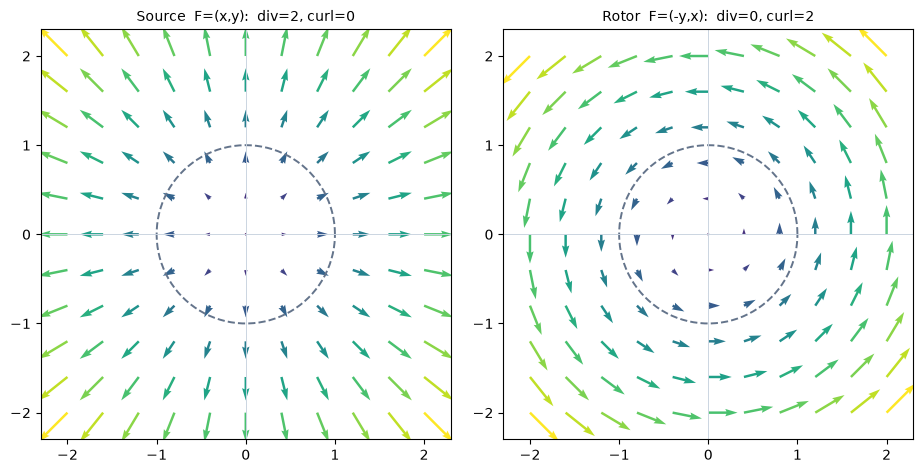

In [6]:
gx, gy = np.meshgrid(np.linspace(-2, 2, 11), np.linspace(-2, 2, 11))
fields = [("Source  F=(x,y):  div=2, curl=0", gx, gy),
          ("Rotor  F=(-y,x):  div=0, curl=2", -gy, gx)]
fig, axes = plt.subplots(1, 2, figsize=(9.4, 4.6))
for ax, (title, U, V) in zip(axes, fields):
    ax.quiver(gx, gy, U, V, np.hypot(U, V), cmap="viridis", scale=28, width=0.006)
    th = np.linspace(0, 2 * np.pi, 200)
    ax.plot(np.cos(th), np.sin(th), "--", color="#64748b", lw=1.4)   # boundary loop / box
    ax.set_title(title, fontsize=10)
    ax.set_xlim(-2.3, 2.3); ax.set_ylim(-2.3, 2.3); ax.set_aspect("equal")
    ax.axhline(0, color="#cbd5e1", lw=.7); ax.axvline(0, color="#cbd5e1", lw=.7)
fig.tight_layout()
plt.show()

## 11. 발산정리: 내부의 원천과 경계의 플럭스
$\displaystyle\iiint_V \nabla\cdot\mathbf F\,dV=\iint_{\partial V}\mathbf F\cdot\mathbf n\,dS$.
$\mathbf F=(x,y,z)$, $V=$ 반지름 $R$ 구로 양변을 직접 계산해 같은 값이 나오는지 봅니다.
좌변: $\nabla\cdot\mathbf F=3$ 이므로 $3\cdot\mathrm{Vol}=4\pi R^3$. 우변: 구면 위 $\mathbf F\cdot\mathbf n=R$.

In [7]:
R = sp.symbols("R", positive=True)
F3 = [x, y, z]
divF = sum(sp.diff(F3[i], c) for i, c in enumerate((x, y, z)))
lhs = sp.integrate(divF * (4 * sp.pi * R**2), (R, 0, R)) if False else divF * sp.Rational(4, 3) * sp.pi * R**3
# flux: on sphere of radius R, F·n = (x,y,z)·(x,y,z)/R = R, integrated over area 4πR²
rhs = R * 4 * sp.pi * R**2
print("div F            =", divF)
print("LHS  ∭ div F dV  =", sp.simplify(lhs))
print("RHS  ∬ F·n dS    =", sp.simplify(rhs))
print("equal ?          =", sp.simplify(lhs - rhs) == 0)

div F            = 3
LHS  ∭ div F dV  = 4*pi*R**3
RHS  ∬ F·n dS    = 4*pi*R**3
equal ?          = True


## 12. 발산의 계산 감각과 다음 질문
발산 정의 $\nabla\cdot\mathbf F=\partial_x F_x+\partial_y F_y(+\partial_z F_z)$ 를 일반 벡터장에서 직접.
회전형 장의 폐경로(단위원) 선적분이 회전과 맞물리는지도 확인합니다.

In [8]:
Fx, Fy = sp.exp(x) * sp.sin(y), x**2 - y**2
print("F = (e^x sin y,  x^2 - y^2)")
print("  div  =", sp.simplify(div2([Fx, Fy])))
print("  curl =", sp.simplify(curl2([Fx, Fy])))

# closed-loop line integral of rotor field F=(-y,x) around the unit circle = 2*area = 2π
Frot = [-sp.sin(t), sp.cos(t)]               # F evaluated on r(t)=(cos t, sin t)
rpath = [sp.cos(t), sp.sin(t)]
dr = [sp.diff(c, t) for c in rpath]
circ = sp.integrate(Frot[0] * dr[0] + Frot[1] * dr[1], (t, 0, 2 * sp.pi))
print("closed line integral of (-y,x) around unit circle =", circ, " (= curl * area = 2*pi)")

F = (e^x sin y,  x^2 - y^2)
  div  = -2*y + exp(x)*sin(y)
  curl = 2*x - exp(x)*cos(y)
closed line integral of (-y,x) around unit circle = 2*pi  (= curl * area = 2*pi)
